In [ ]:
import torch
from torch import nn

print("PyTorch is ready!")

PyTorch is ready!


In [ ]:
def build_model(num_layers, nodes_per_layer):
    layers = [nn.Flatten()]
    input_size = 784

    for _ in range(num_layers):
        layers.append(nn.Linear(input_size, nodes_per_layer))
        layers.append(nn.ReLU())
        input_size = nodes_per_layer

    layers.append(nn.Linear(input_size, 10))

    return nn.Sequential(*layers)

In [ ]:
model = build_model(2, 64)
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=64, bias=True)
  (2): ReLU()
  (3): Linear(in_features=64, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)


In [ ]:
model2 = build_model(3, 32)
print(model2)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=32, bias=True)
  (2): ReLU()
  (3): Linear(in_features=32, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=32, bias=True)
  (6): ReLU()
  (7): Linear(in_features=32, out_features=10, bias=True)
)


In [ ]:
from torchvision import datasets, transforms

full_training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

print("Available training images:", len(full_training_data))
print("Test images:", len(test_data))

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 345kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.78MB/s]

Available training images: 60000
Test images: 10000


In [ ]:
from torch.utils.data import DataLoader

EPOCHS = 5
BATCH_SIZE = 128
LEARNING_RATE = 0.001

train_loader = DataLoader(
    full_training_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training setup is ready!")

Training setup is ready!


In [ ]:
def train_model(model):
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE
    )

    model.train()

    for epoch in range(EPOCHS):
        total_loss = 0.0

        for images, labels in train_loader:
            optimizer.zero_grad()

            outputs = model(images)
            loss = loss_function(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)

        average_loss = total_loss / len(train_loader.dataset)
        print(f"Epoch {epoch + 1}/{EPOCHS}, loss: {average_loss:.4f}")

    return model


model = train_model(model)

Epoch 1/5, loss: 0.4693
Epoch 2/5, loss: 0.1973
Epoch 3/5, loss: 0.1484
Epoch 4/5, loss: 0.1159
Epoch 5/5, loss: 0.0951


In [12]:
def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy


accuracy = evaluate_model(model)
print(f"Test accuracy: {accuracy:.2f}%")

Test accuracy: 96.93%


In [13]:
model2 = train_model(model2)

accuracy2 = evaluate_model(model2)
print(f"Model 2 test accuracy: {accuracy2:.2f}%")

Epoch 1/5, loss: 0.6515
Epoch 2/5, loss: 0.2568
Epoch 3/5, loss: 0.2012
Epoch 4/5, loss: 0.1699
Epoch 5/5, loss: 0.1485
Model 2 test accuracy: 95.45%


In [14]:
layer_choices = [1, 2, 3]
node_choices = [10, 20, 40, 80, 160, 200]

configurations = []

for n in layer_choices:
    for m in node_choices:
        configurations.append((n, m))

print("Number of configurations:", len(configurations))
print(configurations)

Number of configurations: 18
[(1, 10), (1, 20), (1, 40), (1, 80), (1, 160), (1, 200), (2, 10), (2, 20), (2, 40), (2, 80), (2, 160), (2, 200), (3, 10), (3, 20), (3, 40), (3, 80), (3, 160), (3, 200)]


In [15]:
def calculate_cost(model):
    return sum(p.numel() for p in model.parameters())

print("Model 1 cost:", calculate_cost(model))
print("Model 2 cost:", calculate_cost(model2))

Model 1 cost: 55050
Model 2 cost: 27562


In [18]:
results = []

for n, m in configurations:
    print(f"\nTraining network: {n} hidden layers, {m} neurons each")

    current_model = build_model(n, m)
    current_model = train_model(current_model)

    accuracy = evaluate_model(current_model)
    cost = calculate_cost(current_model)
    accuracy_drop = 100 - accuracy

    results.append({
        "hidden_layers"

        : n,
        "nodes_per_layer": m,
        "cost": cost,
        "test_accuracy": accuracy,
        "accuracy_drop": accuracy_drop
    })

    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Cost: {cost}")
    print(f"Accuracy drop: {accuracy_drop:.2f}%")

print("\nFinished all configurations!")


Training network: 1 hidden layers, 10 neurons each
Epoch 1/5, loss: 0.7714
Epoch 2/5, loss: 0.3493
Epoch 3/5, loss: 0.3091
Epoch 4/5, loss: 0.2899
Epoch 5/5, loss: 0.2782
Accuracy: 92.43%
Cost: 7960
Accuracy drop: 7.57%

Training network: 1 hidden layers, 20 neurons each
Epoch 1/5, loss: 0.6483
Epoch 2/5, loss: 0.2997
Epoch 3/5, loss: 0.2618
Epoch 4/5, loss: 0.2358
Epoch 5/5, loss: 0.2176
Accuracy: 93.68%
Cost: 15910
Accuracy drop: 6.32%

Training network: 1 hidden layers, 40 neurons each
Epoch 1/5, loss: 0.5408
Epoch 2/5, loss: 0.2653
Epoch 3/5, loss: 0.2148
Epoch 4/5, loss: 0.1806
Epoch 5/5, loss: 0.1565
Accuracy: 95.46%
Cost: 31810
Accuracy drop: 4.54%

Training network: 1 hidden layers, 80 neurons each
Epoch 1/5, loss: 0.4557
Epoch 2/5, loss: 0.2199
Epoch 3/5, loss: 0.1647
Epoch 4/5, loss: 0.1305
Epoch 5/5, loss: 0.1073
Accuracy: 96.79%
Cost: 63610
Accuracy drop: 3.21%

Training network: 1 hidden layers, 160 neurons each
Epoch 1/5, loss: 0.3960
Epoch 2/5, loss: 0.1792
Epoch 3/5, l

In [19]:
pareto_results = []

for candidate in results:
    dominated = False

    for other in results:
        no_worse = (
            other["cost"] <= candidate["cost"]
            and other["accuracy_drop"] <= candidate["accuracy_drop"]
        )

        strictly_better = (
            other["cost"] < candidate["cost"]
            or other["accuracy_drop"] < candidate["accuracy_drop"]
        )

        if no_worse and strictly_better:
            dominated = True
            break

    if not dominated:
        pareto_results.append(candidate)

print("Number of Pareto configurations:", len(pareto_results))

Number of Pareto configurations: 11


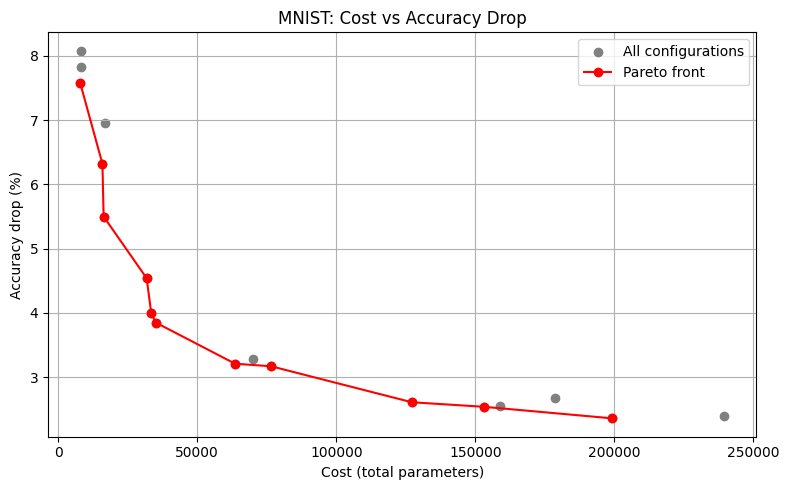

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    [r["cost"] for r in results],
    [r["accuracy_drop"] for r in results],
    color="gray",
    label="All configurations"
)

pareto_sorted = sorted(pareto_results, key=lambda r: r["cost"])

plt.plot(
    [r["cost"] for r in pareto_sorted],
    [r["accuracy_drop"] for r in pareto_sorted],
    "ro-",
    label="Pareto front"
)

plt.xlabel("Cost (total parameters)")
plt.ylabel("Accuracy drop (%)")
plt.title("MNIST: Cost vs Accuracy Drop")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pareto_front.png", dpi=300)
plt.show()